In [ ]:

from google.colab import drive
drive.mount('/content/drive')

import os

BASE_PATH = "/content/drive/MyDrive/FinalProject/new data"

METADATA_PATH = os.path.join(BASE_PATH, "HAM10000_metadata.csv")
IMAGES_PATH   = os.path.join(BASE_PATH, "images")

print("Drive connected successfully.")
print(" Base path:", BASE_PATH)
print(" Metadata:", METADATA_PATH)
print(" Images folder:", IMAGES_PATH)

print("Images folder exists:", os.path.exists(IMAGES_PATH))
print("Metadata file exists:", os.path.exists(METADATA_PATH))



Mounted at /content/drive
Drive connected successfully.
 Base path: /content/drive/MyDrive/FinalProject/new data
 Metadata: /content/drive/MyDrive/FinalProject/new data/HAM10000_metadata.csv
 Images folder: /content/drive/MyDrive/FinalProject/new data/images
Images folder exists: True
Metadata file exists: True


In [ ]:

import pandas as pd

df = pd.read_csv(METADATA_PATH)

print(" Metadata loaded successfully!")
print(" ROWS: ", len(df))
print(" COL:")
print(df.columns)

print("\n  EXAMPLES")
df.head()


 Metadata loaded successfully!
 ROWS:  10015
 COL:
Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization'], dtype='object')

  EXAMPLES


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:

import os

image_files = os.listdir(IMAGES_PATH)
image_files_set = set(image_files)

print("NUM OF IMG:", len(image_files))

expected_files = set(df["image_id"].astype(str) + ".jpg")

print(" NUM OF IMG BY DATA:", len(expected_files))




NUM OF IMG: 10015
 NUM OF IMG BY DATA: 10015


In [ ]:


print("DX::")
print(df["dx"].value_counts(), "\n")

CLASS_NAMES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
print("CLASS_NAMES:", CLASS_NAMES, "\n")

dx_to_idx = {name: i for i, name in enumerate(CLASS_NAMES)}

df["dx_idx"] = df["dx"].map(dx_to_idx)


suspicious_map = {
    "mel": 1,
    "bcc": 1,
    "akiec": 1,
    "nv": 0,
    "bkl": 0,
    "df": 0,
    "vasc": 0
}

df["suspicious"] = df["dx"].map(suspicious_map)

print(df["suspicious"].value_counts(), "\n")

print(df.groupby(["dx", "suspicious"]).size())


DX::
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64 

CLASS_NAMES: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'] 

suspicious
0    8061
1    1954
Name: count, dtype: int64 

dx     suspicious
akiec  1              327
bcc    1              514
bkl    0             1099
df     0              115
mel    1             1113
nv     0             6705
vasc   0              142
dtype: int64


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import timm
from sklearn.model_selection import train_test_split
import numpy as np


In [ ]:
df = df.dropna(subset=["image_id"]).reset_index(drop=True)

NUM_CLASSES = 2


In [ ]:
train_df = pd.read_csv("/content/drive/MyDrive/FinalProject/splits/train_df.csv")
val_df   = pd.read_csv("/content/drive/MyDrive/FinalProject/splits/val_df.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/FinalProject/splits/test_df.csv")

print("Loaded saved splits!")
print(" Train:", len(train_df))
print(" Val:", len(val_df))
print(" Test:", len(test_df))

Loaded saved splits!
 Train: 7010
 Val: 1502
 Test: 1503


In [ ]:
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(300, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


In [ ]:
class SkinDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["image_id"] + ".jpg")

        try:
            img = Image.open(img_path).convert("RGB")
        except:
            print(" Error loading:", img_path)
            img = Image.fromarray(np.zeros((300,300,3), dtype=np.uint8))

        label = torch.tensor(int(row["suspicious"]), dtype=torch.long)
        img_id = row["image_id"]

        if self.transform:
            img = self.transform(img)

        return img, label, img_id



In [ ]:
train_dataset = SkinDataset(train_df, IMAGES_PATH, train_transforms)
val_dataset   = SkinDataset(val_df,   IMAGES_PATH, val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print("Loaders ready!")


Loaders ready!


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = timm.create_model(
    "efficientnet_b3",
    pretrained=True,
    num_classes=NUM_CLASSES
).to(device)

model


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

EfficientNet(
  (conv_stem): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
        (bn1): BatchNormAct2d(
          40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(40, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (b

In [ ]:
# label balancing - using the training set only
pos_weight = len(train_df[train_df.suspicious == 0]) / len(train_df[train_df.suspicious == 1])
class_weights = torch.tensor([1.0, pos_weight], device=device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)



In [ ]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_val_loss = float("inf")


In [ ]:
import os
MODEL_DIR = "/content/drive/MyDrive/FinalProject/models"
os.makedirs(MODEL_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(MODEL_DIR, "best_model.pth")



In [ ]:
from tqdm import tqdm
import time

EPOCHS = 20

for epoch in range(EPOCHS):
    print(f"\n Epoch {epoch+1}/{EPOCHS}")
    start_time = time.time()

    # TRAIN
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    pbar = tqdm(train_loader, desc="Training", leave=False)

    for images, labels, _ in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{train_correct/train_total:.4f}"
        })

    scheduler.step()

    #  VALIDATION
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        pbar_val = tqdm(val_loader, desc="Validating", leave=False)
        for images, labels, _ in pbar_val:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

            pbar_val.set_postfix({
                "loss": f"{loss.item():.4f}"
            })

    epoch_time = time.time() - start_time

    train_loss_epoch = train_loss/len(train_loader)
    val_loss_epoch = val_loss/len(val_loader)
    train_acc_epoch = train_correct/train_total
    val_acc_epoch = val_correct/val_total

    history["train_loss"].append(train_loss_epoch)
    history["val_loss"].append(val_loss_epoch)
    history["train_acc"].append(train_acc_epoch)
    history["val_acc"].append(val_acc_epoch)

    # SAVE BEST MODEL TO DRIVE
    if val_loss_epoch < best_val_loss:
        best_val_loss = val_loss_epoch
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print("Saved BEST model:", BEST_MODEL_PATH)

    print("Epoch Complete")
    print(f"Train Loss: {train_loss_epoch:.4f}  |  Train Acc: {train_acc_epoch:.4f}")
    print(f"Val   Loss: {val_loss_epoch:.4f}  |  Val   Acc: {val_acc_epoch:.4f}")
    print(f" Time: {epoch_time:.2f} sec")
    print("-" * 50)



 Epoch 1/20


Saved BEST model: /content/drive/MyDrive/FinalProject/models/best_model.pth
Epoch Complete
Train Loss: 0.7681  |  Train Acc: 0.7535
Val   Loss: 0.4824  |  Val   Acc: 0.7983
 Time: 667.96 sec
--------------------------------------------------

 Epoch 2/20


Saved BEST model: /content/drive/MyDrive/FinalProject/models/best_model.pth
Epoch Complete
Train Loss: 0.3631  |  Train Acc: 0.8227
Val   Loss: 0.3863  |  Val   Acc: 0.8089
 Time: 92.45 sec
--------------------------------------------------

 Epoch 3/20


Saved BEST model: /content/drive/MyDrive/FinalProject/models/best_model.pth
Epoch Complete
Train Loss: 0.3134  |  Train Acc: 0.8649
Val   Loss: 0.3794  |  Val   Acc: 0.8522
 Time: 92.62 sec
--------------------------------------------------

 Epoch 4/20


Saved BEST model: /content/drive/MyDrive/FinalProject/models/best_model.pth
Epoch Complete
Train Loss: 0.2678  |  Train Acc: 0.8825
Val   Loss: 0.3661  |  Val   Acc: 0.8628
 Time: 93.01 sec
--------------------------------------------------

 Epoch 5/20


...

Epoch Complete
Train Loss: 0.0273  |  Train Acc: 0.9902
Val   Loss: 0.6740  |  Val   Acc: 0.9234
 Time: 92.64 sec
--------------------------------------------------

 Epoch 17/20


Epoch Complete
Train Loss: 0.0201  |  Train Acc: 0.9934
Val   Loss: 0.6548  |  Val   Acc: 0.9274
 Time: 92.80 sec
--------------------------------------------------

 Epoch 18/20


Epoch Complete
Train Loss: 0.0152  |  Train Acc: 0.9947
Val   Loss: 0.6821  |  Val   Acc: 0.9288
 Time: 92.92 sec
--------------------------------------------------

 Epoch 19/20


Epoch Complete
Train Loss: 0.0148  |  Train Acc: 0.9947
Val   Loss: 0.5969  |  Val   Acc: 0.9241
 Time: 92.60 sec
--------------------------------------------------

 Epoch 20/20


Epoch Complete
Train Loss: 0.0148  |  Train Acc: 0.9960
Val   Loss: 0.5850  |  Val   Acc: 0.9234
 Time: 92.85 sec
--------------------------------------------------


In [ ]:
# Test dataset & loader
test_dataset = SkinDataset(test_df, IMAGES_PATH, val_transforms)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print("Test loader ready!  Size:", len(test_dataset))


Test loader ready!  Size: 1503


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

MODEL_PATH = "/content/drive/MyDrive/FinalProject/models/best_model.pth"

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()


all_test_labels = []
all_test_preds  = []
all_test_probs  = []

with torch.no_grad():
    for images, labels, _ in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs   = torch.softmax(outputs, dim=1)[:, 1]
        preds   = torch.argmax(outputs, dim=1)

        all_test_labels.extend(labels.cpu().numpy())
        all_test_preds.extend(preds.cpu().numpy())
        all_test_probs.extend(probs.cpu().numpy())

test_acc = accuracy_score(all_test_labels, all_test_preds)
print(f"Test Accuracy: {test_acc:.4f}")


Test Accuracy: 0.8523


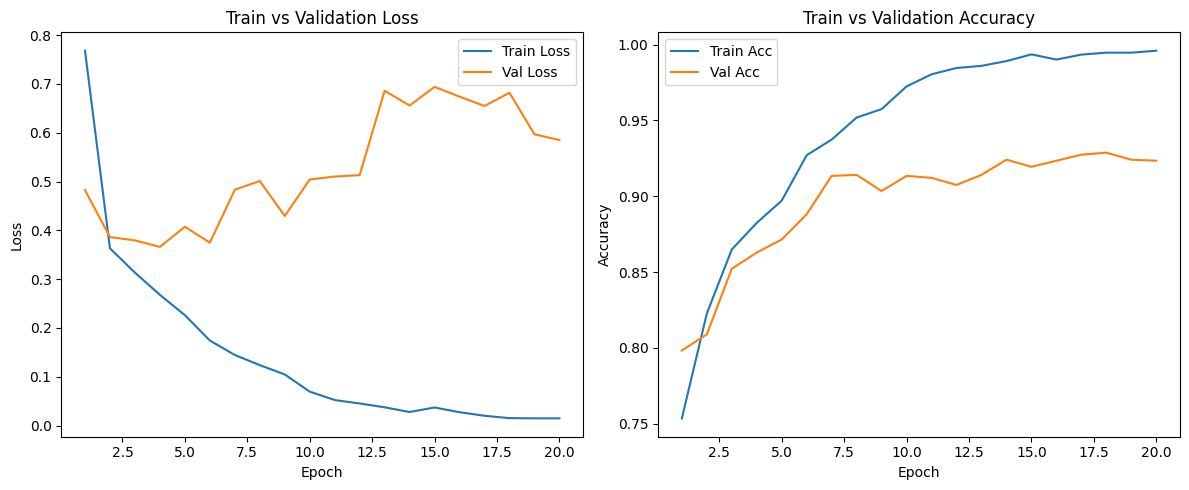

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


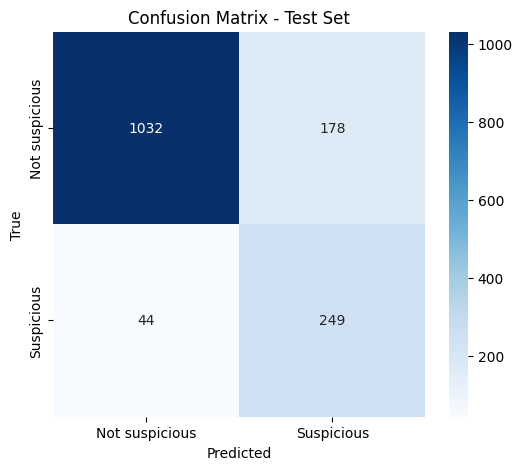

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_test_labels, all_test_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not suspicious", "Suspicious"],
            yticklabels=["Not suspicious", "Suspicious"])
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [ ]:
print(classification_report(all_test_labels,
                            all_test_preds,
                            target_names=["Not suspicious", "Suspicious"]))


                precision    recall  f1-score   support

Not suspicious       0.96      0.85      0.90      1210
    Suspicious       0.58      0.85      0.69       293

      accuracy                           0.85      1503
     macro avg       0.77      0.85      0.80      1503
  weighted avg       0.89      0.85      0.86      1503



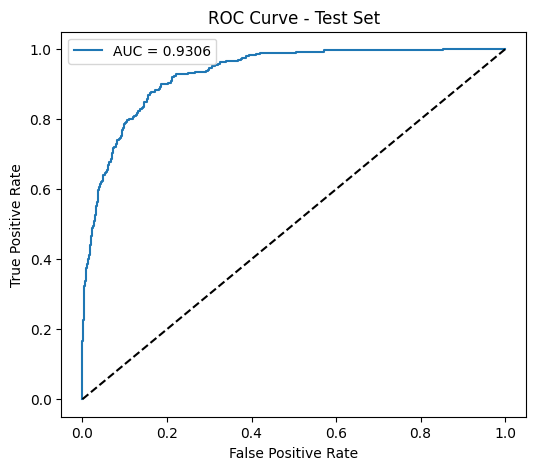

 Test ROC-AUC: 0.9306


In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(all_test_labels, all_test_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Set")
plt.legend()
plt.show()

print(f" Test ROC-AUC: {roc_auc:.4f}")


In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(all_test_labels, all_test_probs)

youden_j = tpr - fpr
best_idx = youden_j.argmax()
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.4f}")
print(f"TPR: {tpr[best_idx]:.4f}, FPR: {fpr[best_idx]:.4f}")


Best threshold: 0.4259
TPR: 0.8771, FPR: 0.1612
